# PA4 — Document Analyst: Graph Build + Test Queries (Task 1.7 / Task 2.4)

Self-contained notebook — bundles the `agent`/`rag`/`tools` packages inline (rather than
`import agent.graph`) so it can be uploaded and run directly on Databricks without a
linked Git folder. The canonical source of truth is the repo (`agent/`, `rag/`,
`tools/mcp_server.py`, `config.py`); this notebook mirrors that code manually.

**Before running:** fill in the settings cell below with your own workspace values
(same ones as in your local `.env` / the `pa4_ingest.ipynb` notebook).


In [ ]:
%pip install langgraph langchain langchain-core langchain-openai databricks-langchain \
    databricks-vectorsearch mcp langchain-mcp-adapters
dbutils.library.restartPython()

In [ ]:
import os

# Fill these in to match your workspace.
os.environ["DATABRICKS_HOST"] = "https://your-workspace.databricks.com"
os.environ["DATABRICKS_TOKEN"] = "dapi..."
os.environ["DATABRICKS_MODEL"] = "databricks-meta-llama-3-3-70b-instruct"
os.environ["EMBEDDINGS_ENDPOINT"] = "databricks-gte-large-en"
os.environ["VECTOR_SEARCH_ENDPOINT"] = "cs4603_rag_endpoint"
os.environ["VECTOR_SEARCH_INDEX"] = "cs4603.default.emanqureshi_analyst_index"

## Config — LLM + retriever factories

Mirrors `config.py` + `rag/store.py`.

In [3]:
from functools import lru_cache


def get_settings():
    return {
        "host": os.environ["DATABRICKS_HOST"].rstrip("/"),
        "token": os.environ["DATABRICKS_TOKEN"],
        "model": os.environ["DATABRICKS_MODEL"],
        "embeddings": os.environ.get("EMBEDDINGS_ENDPOINT", "databricks-gte-large-en"),
        "vs_endpoint": os.environ.get("VECTOR_SEARCH_ENDPOINT", ""),
        "vs_index": os.environ.get("VECTOR_SEARCH_INDEX", ""),
    }


@lru_cache(maxsize=1)
def get_chat_llm(temperature: float = 0.0):
    from langchain_openai import ChatOpenAI

    s = get_settings()
    return ChatOpenAI(
        model=s["model"],
        api_key=s["token"],
        base_url=f"{s['host']}/serving-endpoints",
        temperature=temperature,
    )


def get_retriever(k: int = 4):
    from databricks_langchain import DatabricksVectorSearch

    s = get_settings()
    vector_store = DatabricksVectorSearch(
        index_name=s["vs_index"],
        columns=["chunk_id", "chunk_to_retrieve", "source", "page"],
    )
    return vector_store.as_retriever(search_kwargs={"k": k})

## State schema (Task 1.1)

Mirrors `agent/state.py`.

In [4]:
from typing import Annotated, TypedDict

from langgraph.graph.message import add_messages


class AnalystState(TypedDict):
    messages: Annotated[list, add_messages]
    plan: list[str]
    current_step_index: int
    step_results: list[str]
    next_agent: str
    final_answer: str

## Prompts (Task 1.2-1.6)

Mirrors `agent/prompts.py`.

In [5]:
PLANNER_PROMPT = """You are the planning module of a financial document analyst system.
Given a user's question, decompose it into 2 to 5 atomic, ordered steps needed to answer it completely.

Each step must be one of two kinds:
  - a DOCUMENT RETRIEVAL step: asks for a specific fact, figure, or statement found in a \
financial report (e.g. "Find Meridian's net revenue for fiscal year 2023")
  - a CALCULATION step: asks for a numeric computation performed on already-known values \
(e.g. "Calculate 16.91 trillion compounded at 8% annual growth for 3 years")

Respond with ONLY a JSON array of strings, one per step, in the order they should be executed. \
Do not include any other text, explanation, or markdown formatting.
If the question requires only a single fact or a single calculation, return a one-element array.
"""

SUPERVISOR_PROMPT = """You are the routing supervisor of a financial document analyst system.
You will be given the text of a single plan step. Decide which specialist should execute it:
  - Respond with exactly the word "rag_agent" if the step requires looking up a fact, figure, \
or statement from a document.
  - Respond with exactly the word "mcp_tools" if the step requires a mathematical or numeric \
calculation (growth, percentage, comparison, unit conversion, arithmetic).
Respond with ONLY one of these two words and nothing else.
"""

RAG_EXTRACT_PROMPT = """You are the fact-extraction module of a financial document analyst system.
You will be given a plan step (the fact being sought) and a set of retrieved document chunks, \
each prefixed with its citation in the form [source: <file>, p.<page>].

Extract the single fact that answers the step, and state it concisely with its citation inline, \
e.g. "Net revenue in FY2023 was 16.91 trillion [source: annual_report.pdf, p.4]".
If none of the retrieved chunks contain the requested fact, respond with exactly: \
not found in documents
Do not fabricate a number that is not present in the retrieved chunks.
"""

MCP_STEP_PROMPT = """You are the calculation module of a financial document analyst system.
You will be given prior step results (which may contain figures you need) and the current plan \
step describing a calculation to perform.
Call EXACTLY ONE of the available tools with the correct arguments to perform this calculation. \
Extract any numeric values you need from the prior results text.
Do not attempt to compute the answer yourself in text — always use a tool call.
"""

SYNTHESIZER_PROMPT = """You are the synthesis module of a financial document analyst system.
You will be given the ordered plan steps and their results (facts retrieved from documents, \
and/or calculations performed by tools).
Combine them into one clear, coherent answer to the user's original question. Preserve \
citations from any retrieved facts (e.g. [source: file, p.N]).
If a step's result is "not found in documents", acknowledge the gap honestly rather than \
guessing.
Respond with the final answer only — no preamble.
"""

## Planner node (Task 1.2)

Mirrors `agent/planner.py`.

In [6]:
import json
import re

from langchain_core.messages import HumanMessage, SystemMessage


def _parse_plan(text: str) -> list[str]:
    match = re.search(r"\[.*\]", text, re.DOTALL)
    if not match:
        raise ValueError("no JSON array found in planner output")
    steps = json.loads(match.group(0))
    if not isinstance(steps, list) or not steps or not all(isinstance(s, str) for s in steps):
        raise ValueError("planner output is not a non-empty list of strings")
    return steps


def make_planner(llm):
    def planner(state: AnalystState) -> dict:
        question = state["messages"][-1].content
        response = llm.invoke(
            [SystemMessage(content=PLANNER_PROMPT), HumanMessage(content=question)]
        )
        try:
            plan = _parse_plan(response.content)
        except (ValueError, json.JSONDecodeError):
            plan = [question]
        return {"plan": plan, "current_step_index": 0, "step_results": []}

    return planner

## Supervisor node (Task 1.3)

Mirrors `agent/supervisor.py`.

In [7]:
RAG = "rag_agent"
MCP = "mcp_tools"
SYNTH = "synthesizer"


def make_supervisor(llm):
    def supervisor(state: AnalystState) -> dict:
        plan = state.get("plan", [])
        index = state.get("current_step_index", 0)
        if index >= len(plan):
            return {"next_agent": SYNTH}

        step = plan[index]
        response = llm.invoke(
            [SystemMessage(content=SUPERVISOR_PROMPT), HumanMessage(content=step)]
        )
        decision = response.content.strip().lower()
        next_agent = MCP if MCP in decision else RAG
        return {"next_agent": next_agent}

    return supervisor


def route_from_supervisor(state: AnalystState) -> str:
    return state["next_agent"]

## RAG agent node (Task 1.4)

Mirrors `agent/rag_agent.py`.

In [8]:
def format_docs(docs) -> str:
    # page_content holds chunk_to_embed (the embedding source column) —
    # display chunk_to_retrieve from metadata instead, the clean text meant
    # to be shown to the LLM/user, not the embedding input.
    if not docs:
        return ""
    lines = []
    for doc in docs:
        text = doc.metadata.get("chunk_to_retrieve", doc.page_content)
        source = doc.metadata.get("source", "unknown")
        page = doc.metadata.get("page", "?")
        if isinstance(page, float) and page.is_integer():
            page = int(page)
        lines.append(f"[source: {source}, p.{page}] {text}")
    return "\n\n".join(lines)


def make_rag_agent(retriever, llm):
    def rag_agent(state: AnalystState) -> dict:
        plan = state["plan"]
        index = state["current_step_index"]
        step = plan[index]

        docs = retriever.invoke(step)
        context = format_docs(docs)

        if not context:
            fact = "not found in documents"
        else:
            response = llm.invoke(
                [
                    SystemMessage(content=RAG_EXTRACT_PROMPT),
                    HumanMessage(content=f"Step: {step}\n\nRetrieved context:\n{context}"),
                ]
            )
            fact = response.content.strip()

        step_results = state.get("step_results", []) + [fact]
        return {"step_results": step_results, "current_step_index": index + 1}

    return rag_agent

## Synthesizer node (Task 1.6)

Mirrors `agent/synthesizer.py`.

In [9]:
from langchain_core.messages import AIMessage


def make_synthesizer(llm):
    def synthesizer(state: AnalystState) -> dict:
        plan = state.get("plan", [])
        step_results = state.get("step_results", [])

        context = "\n".join(
            f"Step {i + 1}: {step}\nResult: {result}"
            for i, (step, result) in enumerate(zip(plan, step_results, strict=False))
        )

        response = llm.invoke(
            [SystemMessage(content=SYNTHESIZER_PROMPT), HumanMessage(content=context)]
        )
        final_answer = response.content.strip()

        return {
            "final_answer": final_answer,
            "messages": [AIMessage(content=final_answer)],
        }

    return synthesizer

## MCP tool server + tool node (Task 1.5)

Writes the GIVEN `tools/mcp_server.py` source to a local file on the cluster so it can be
spawned as a stdio subprocess (mirrors `agent/graph.py::load_mcp_tools` /
`make_mcp_node`). The tool source itself is unmodified from the repo.

In [10]:
MCP_SERVER_SOURCE = '"""\nCS4603 PA4 — MCP tool server  [GIVEN — do not modify]\n=====================================================\n\nExposes deterministic math / finance tools over the Model Context Protocol\n(stdio transport). Your LangGraph supervisor routes calculation steps here so\nnumbers are computed by real Python, not hallucinated by the LLM.\n\nRun standalone (for a quick smoke test):\n\n    uv run python tools/mcp_server.py\n\nYour agent connects to it programmatically via `langchain-mcp-adapters`\n(see agent/graph.py). The five tools below match PA4 Task 0.2.\n"""\n\nfrom __future__ import annotations\n\nimport ast\nimport operator\n\nfrom mcp.server.fastmcp import FastMCP\n\nmcp = FastMCP("cs4603-analyst-tools")\n\n\n# ─── Safe arithmetic evaluator ───────────────────────────────────────────────\n# We evaluate `calculate` with a whitelisted AST walker instead of eval() so a\n# malicious or malformed expression can never execute arbitrary code.\n\n_BIN_OPS = {\n    ast.Add: operator.add,\n    ast.Sub: operator.sub,\n    ast.Mult: operator.mul,\n    ast.Div: operator.truediv,\n    ast.Pow: operator.pow,\n    ast.Mod: operator.mod,\n    ast.FloorDiv: operator.floordiv,\n}\n_UNARY_OPS = {ast.UAdd: operator.pos, ast.USub: operator.neg}\n\n\ndef _safe_eval(node: ast.AST) -> float:\n    if isinstance(node, ast.Expression):\n        return _safe_eval(node.body)\n    if isinstance(node, ast.Constant):\n        if isinstance(node.value, (int, float)):\n            return float(node.value)\n        raise ValueError(f"Unsupported constant: {node.value!r}")\n    if isinstance(node, ast.BinOp) and type(node.op) in _BIN_OPS:\n        return _BIN_OPS[type(node.op)](_safe_eval(node.left), _safe_eval(node.right))\n    if isinstance(node, ast.UnaryOp) and type(node.op) in _UNARY_OPS:\n        return _UNARY_OPS[type(node.op)](_safe_eval(node.operand))\n    raise ValueError("Expression contains an unsupported operation")\n\n\n# ─── Tools ───────────────────────────────────────────────────────────────────\n\n@mcp.tool()\ndef calculate(expression: str) -> str:\n    """Evaluate a math expression. Supports + - * / ** % and parentheses.\n\n    Args:\n        expression: e.g. "16.91 * (1.08 ** 3)"\n    """\n    try:\n        tree = ast.parse(expression, mode="eval")\n        result = _safe_eval(tree)\n    except (SyntaxError, ValueError, ZeroDivisionError) as exc:\n        return f"Error evaluating \'{expression}\': {exc}"\n    return f"{expression} = {result:g}"\n\n\n@mcp.tool()\ndef percentage_change(old_value: float, new_value: float) -> str:\n    """Compute the percentage change from old_value to new_value.\n\n    Args:\n        old_value: the baseline value\n        new_value: the new value\n    """\n    if old_value == 0:\n        return "Error: percentage change is undefined when old_value is 0"\n    pct = (new_value - old_value) / abs(old_value) * 100\n    direction = "increase" if pct >= 0 else "decrease"\n    return f"{old_value} -> {new_value} is a {pct:+.2f}% {direction}"\n\n\n@mcp.tool()\ndef growth_rate(start_value: float, rate: float, years: float) -> str:\n    """Project a value under compound annual growth: start_value * (1 + rate) ** years.\n\n    Args:\n        start_value: the starting value\n        rate: annual growth rate as a decimal (e.g. 0.08 for 8%)\n        years: number of years to compound\n    """\n    try:\n        projected = start_value * (1 + rate) ** years\n    except (OverflowError, ValueError) as exc:\n        return f"Error computing growth: {exc}"\n    return (\n        f"{start_value:g} at {rate * 100:g}% CAGR for {years:g} years "\n        f"= {projected:g}"\n    )\n\n\n@mcp.tool()\ndef compare_values(a: float, b: float) -> str:\n    """Compare two numbers and report which is larger and by how much (absolute and %).\n\n    Args:\n        a: first value\n        b: second value\n    """\n    if a == b:\n        return f"{a:g} and {b:g} are equal"\n    larger, smaller = (a, b) if a > b else (b, a)\n    diff = larger - smaller\n    pct = (diff / abs(smaller) * 100) if smaller != 0 else float("inf")\n    label = "a" if a > b else "b"\n    return (\n        f"{larger:g} ({label}) is larger by {diff:g} "\n        f"({pct:.2f}% greater than {smaller:g})"\n    )\n\n\n@mcp.tool()\ndef unit_convert(value: float, from_unit: str, to_unit: str) -> str:\n    """Convert a value between common financial-reporting scale units.\n\n    Supported units (case-insensitive): \'ones\', \'thousand\', \'million\',\n    \'billion\', \'trillion\', and \'percent\' <-> \'ratio\'.\n\n    Args:\n        value: the numeric value to convert\n        from_unit: source unit\n        to_unit: target unit\n    """\n    scale = {\n        "ones": 1.0,\n        "thousand": 1e3,\n        "million": 1e6,\n        "billion": 1e9,\n        "trillion": 1e12,\n    }\n    f, t = from_unit.lower().strip(), to_unit.lower().strip()\n\n    # percentage <-> ratio special case\n    if {f, t} == {"percent", "ratio"}:\n        result = value / 100 if f == "percent" else value * 100\n        return f"{value:g} {from_unit} = {result:g} {to_unit}"\n\n    if f not in scale or t not in scale:\n        return (\n            f"Unknown unit. Supported: {\', \'.join(scale)}, percent, ratio "\n            f"(got from=\'{from_unit}\', to=\'{to_unit}\')"\n        )\n    result = value * scale[f] / scale[t]\n    return f"{value:g} {from_unit} = {result:g} {to_unit}"\n\n\nif __name__ == "__main__":\n    # Default transport is stdio — this is what the LangGraph MCP client connects to.\n    mcp.run()\n'

_MCP_SERVER_PATH = "/tmp/pa4_mcp_server.py"
with open(_MCP_SERVER_PATH, "w") as f:
    f.write(MCP_SERVER_SOURCE)

In [11]:
import asyncio
import sys


def _run_async(coro):
    """Run `coro` whether or not an event loop is already running.

    Plain asyncio.run() fails with "cannot be called from a running event
    loop" inside Jupyter/Databricks notebook kernels (they already run their
    own loop). Detect that case and run on a fresh loop in a separate thread.
    """
    try:
        asyncio.get_running_loop()
    except RuntimeError:
        return asyncio.run(coro)

    import concurrent.futures

    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as pool:
        return pool.submit(asyncio.run, coro).result()


def _has_fileno(stream) -> bool:
    try:
        stream.fileno()
        return True
    except (AttributeError, OSError, ValueError):
        return False


def _patch_mcp_stdio_errlog() -> None:
    import mcp.client.stdio as stdio_module

    target = getattr(stdio_module.stdio_client, "__wrapped__", stdio_module.stdio_client)
    if target.__defaults__ and not _has_fileno(target.__defaults__[0]):
        fallback = sys.__stderr__ if sys.__stderr__ and _has_fileno(sys.__stderr__) else open(os.devnull, "w")
        target.__defaults__ = (fallback,)


async def _load_mcp_tools_async(server_path: str):
    _patch_mcp_stdio_errlog()
    from langchain_mcp_adapters.client import MultiServerMCPClient

    client = MultiServerMCPClient(
        {"analyst": {"command": sys.executable, "args": [server_path], "transport": "stdio"}}
    )
    return await client.get_tools()


def load_mcp_tools(server_path: str = _MCP_SERVER_PATH):
    return _run_async(_load_mcp_tools_async(server_path))


def _flatten_tool_result(result) -> str:
    if isinstance(result, list):
        texts = [b.get("text", "") for b in result if isinstance(b, dict) and "text" in b]
        if texts:
            return "\n".join(texts)
    return str(result)


def make_mcp_node(tools, llm, server_path=_MCP_SERVER_PATH):
    _cache = {"tools": tools, "llm_with_tools": None, "tools_by_name": None}

    def _ensure_loaded():
        if _cache["tools"] is None:
            _cache["tools"] = load_mcp_tools(server_path)
        if _cache["llm_with_tools"] is None:
            _cache["llm_with_tools"] = llm.bind_tools(_cache["tools"])
            _cache["tools_by_name"] = {t.name: t for t in _cache["tools"]}

    def mcp_tools(state: AnalystState) -> dict:
        _ensure_loaded()
        llm_with_tools = _cache["llm_with_tools"]
        tools_by_name = _cache["tools_by_name"]

        plan = state["plan"]
        index = state["current_step_index"]
        step = plan[index]
        step_results = state.get("step_results", [])

        prior_results = "\n".join(step_results) or "(none yet)"
        prompt = f"{MCP_STEP_PROMPT}\n\nPrior results:\n{prior_results}\n\nStep: {step}"
        response = llm_with_tools.invoke([HumanMessage(content=prompt)])

        tool_calls = getattr(response, "tool_calls", None) or []
        if not tool_calls:
            result = response.content.strip() or "Error: no tool was called"
        else:
            call = tool_calls[0]
            tool = tools_by_name.get(call["name"])
            if tool is None:
                result = f"Error: unknown tool '{call['name']}'"
            else:
                result = _flatten_tool_result(_run_async(tool.ainvoke(call["args"])))

        return {
            "step_results": step_results + [str(result)],
            "current_step_index": index + 1,
        }

    return mcp_tools

## Build the graph (Task 1.7)

Mirrors `agent/graph.py::build_graph`.

In [12]:
from langgraph.graph import END, START, StateGraph

llm = get_chat_llm()
retriever = get_retriever()
tools = load_mcp_tools()

builder = StateGraph(AnalystState)
builder.add_node("planner", make_planner(llm))
builder.add_node("supervisor", make_supervisor(llm))
builder.add_node("rag_agent", make_rag_agent(retriever, llm))
builder.add_node("mcp_tools", make_mcp_node(tools, llm))
builder.add_node("synthesizer", make_synthesizer(llm))

builder.add_edge(START, "planner")
builder.add_edge("planner", "supervisor")
builder.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {RAG: "rag_agent", MCP: "mcp_tools", SYNTH: "synthesizer"},
)
builder.add_edge("rag_agent", "supervisor")
builder.add_edge("mcp_tools", "supervisor")
builder.add_edge("synthesizer", END)

graph = builder.compile()
print("Graph compiled with nodes:", list(graph.get_graph().nodes))

/Users/eman/Downloads/cs4603-pa4-main/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Graph compiled with nodes: ['__start__', 'planner', 'supervisor', 'rag_agent', 'mcp_tools', 'synthesizer', '__end__']


### Visualize the compiled graph

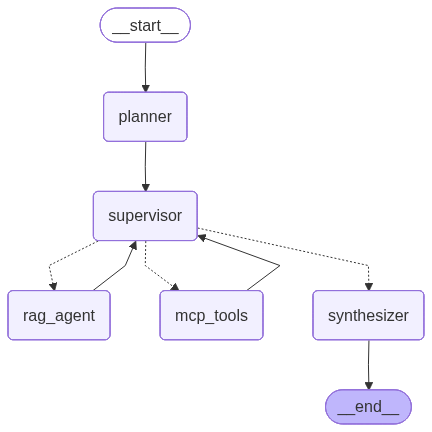

In [13]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Falling back to ASCII / mermaid text (draw_mermaid_png needs extra deps):", exc)
    print(graph.get_graph().draw_mermaid())

## Test queries

### 1. Retrieval-only query

In [14]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What was the net income in 2023?"}]}
)
print("PLAN:", result["plan"])
print("STEP RESULTS:", result["step_results"])
print("ANSWER:", result["messages"][-1].content)

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


PLAN: ["Find the company's net income for fiscal year 2023"]
STEP RESULTS: ['Net income for fiscal year 2023 was ¥1,137 billion [source: annual_report.pdf, p.4]']
ANSWER: The company's net income for fiscal year 2023 was ¥1,137 billion [source: annual_report.pdf, p.4].


### 2. Computation-only query

In [15]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is 15% of 2.4 billion?"}]}
)
print("PLAN:", result["plan"])
print("STEP RESULTS:", result["step_results"])
print("ANSWER:", result["messages"][-1].content)

PLAN: ['Calculate 15% of 2.4 billion']
STEP RESULTS: ['0.15 * 2.4e9 = 3.6e+08']
ANSWER: 15% of 2.4 billion is 360 million.


### 3. Combined query (retrieval + calculation), with a step-by-step execution trace

In [16]:
query = (
    "What was Meridian's net revenue in fiscal year 2023, and what would it be "
    "after 3 years of 8% compound annual growth?"
)

print("=== Step-by-step execution trace ===")
final_state = None
for step_output in graph.stream({"messages": [{"role": "user", "content": query}]}):
    for node_name, node_update in step_output.items():
        print(f"\n--- node: {node_name} ---")
        for key, value in node_update.items():
            print(f"  {key}: {value}")
    final_state = step_output

result = graph.invoke({"messages": [{"role": "user", "content": query}]})
print("\n=== Final answer ===")
print(result["messages"][-1].content)

=== Step-by-step execution trace ===



--- node: planner ---
  plan: ["Find Meridian's net revenue for fiscal year 2023", 'Calculate the result compounded at 8% annual growth for 3 years']
  current_step_index: 0
  step_results: []



--- node: supervisor ---
  next_agent: rag_agent
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.



--- node: rag_agent ---
  step_results: ['Net revenue in FY2023 was 16,910 billion [source: annual_report.pdf, p.4]']
  current_step_index: 1



--- node: supervisor ---
  next_agent: mcp_tools



--- node: mcp_tools ---
  step_results: ['Net revenue in FY2023 was 16,910 billion [source: annual_report.pdf, p.4]', '16.91 at 8% CAGR for 3 years = 21.3017']
  current_step_index: 2

--- node: supervisor ---
  next_agent: synthesizer



--- node: synthesizer ---
  final_answer: Meridian's net revenue for fiscal year 2023 was $16.91 billion [source: annual_report.pdf, p.4]. If this amount is compounded at an 8% annual growth rate for 3 years, the projected result would be approximately $21.30 billion.
  messages: [AIMessage(content="Meridian's net revenue for fiscal year 2023 was $16.91 billion [source: annual_report.pdf, p.4]. If this amount is compounded at an 8% annual growth rate for 3 years, the projected result would be approximately $21.30 billion.", additional_kwargs={}, response_metadata={}, id='e1636037-1e86-4183-b9e9-c18ac52eac88', tool_calls=[], invalid_tool_calls=[])]


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.



=== Final answer ===
Meridian's net revenue for fiscal year 2023 was $16.91 billion [source: annual_report.pdf, p.4]. If this amount is compounded at an 8% annual growth rate for 3 years, the projected result would be approximately $21.30 billion.


## Part 2 — Testing the Deployed Endpoint (Task 2.4)

Calls the live serving endpoint deployed in Part 2 (`emanqureshi-document-analyst`) — not the local
in-notebook graph above. Uses `DATABRICKS_HOST`/`DATABRICKS_TOKEN`/`SERVING_ENDPOINT_NAME` already set
in the settings cell at the top of this notebook.

### 1. Call the endpoint with `curl`, show the raw response

In [42]:
import subprocess

curl_cmd = [
    "curl", "-s", "-X", "POST",
    f"{os.environ['DATABRICKS_HOST']}/serving-endpoints/{os.environ.get('SERVING_ENDPOINT_NAME', 'emanqureshi-document-analyst')}/invocations",
    "-H", f"Authorization: Bearer {os.environ['DATABRICKS_TOKEN']}",
    "-H", "Content-Type: application/json",
    "-d", '{"messages": [{"role": "user", "content": "What was the net income in 2023?"}]}',
]
raw = subprocess.run(curl_cmd, capture_output=True, text=True).stdout
print(raw)

[{"messages": [{"content": "What was the net income in 2023?", "additional_kwargs": {}, "response_metadata": {}, "type": "human", "name": null, "id": "e89a2a14-d745-40ca-bbea-6f14acc88dff"}, {"content": "The company's net income for fiscal year 2023 was \u00a51,137 billion [source: annual_report.pdf, p.4].", "additional_kwargs": {}, "response_metadata": {}, "type": "ai", "name": null, "id": "60379947-a5da-40a5-b72d-53884b97e777", "tool_calls": [], "invalid_tool_calls": [], "usage_metadata": null}], "plan": ["Find the company's net income for fiscal year 2023"], "current_step_index": 1, "step_results": ["Net income for fiscal year 2023 was \u00a51,137 billion [source: annual_report.pdf, p.4]"], "next_agent": "synthesizer", "final_answer": "The company's net income for fiscal year 2023 was \u00a51,137 billion [source: annual_report.pdf, p.4]."}]


### 2. Call the endpoint with the OpenAI Python SDK, show the parsed response

**Real, documented failure mode, not papered over:** the response comes back as a raw list wrapping
our graph's own `AnalystState` dict, not an OpenAI `ChatCompletion`. MLflow only auto-wraps a served
model's output into the OpenAI envelope when its schema is pure messages-only
(`ChatCompletionResponse`/`StringResponse`); our state has extra fields (`plan`, `step_results`,
`current_step_index`, `next_agent`, `final_answer`), so MLflow serves it as-is. `client/sdk.py`'s
`_extract_content()` handles both shapes so the client SDK (Part 3, below) works regardless.

In [43]:
import openai

openai_client = openai.OpenAI(
    api_key=os.environ["DATABRICKS_TOKEN"],
    base_url=f"{os.environ['DATABRICKS_HOST']}/serving-endpoints",
)

response = openai_client.chat.completions.create(
    model=os.environ.get("SERVING_ENDPOINT_NAME", "emanqureshi-document-analyst"),
    messages=[{"role": "user", "content": "What was the net income in 2023?"}],
)
try:
    print(response.choices[0].message.content)
except AttributeError as exc:
    print(f"AttributeError: {exc}")
    print("response is actually a raw list, not a ChatCompletion:", type(response))

AttributeError: 'list' object has no attribute 'choices'
response is actually a raw list, not a ChatCompletion: <class 'list'>


### 3. Run the same 3 test queries against the deployed endpoint

In [44]:
import requests

url = f"{os.environ['DATABRICKS_HOST']}/serving-endpoints/{os.environ.get('SERVING_ENDPOINT_NAME', 'emanqureshi-document-analyst')}/invocations"
headers = {"Authorization": f"Bearer {os.environ['DATABRICKS_TOKEN']}", "Content-Type": "application/json"}

deployed_queries = [
    "What was the net income in 2023?",
    "What is 15% of 2.4 billion?",
    "What was Meridian's net revenue in fiscal year 2023, and what would it be after 3 years of 8% compound annual growth?",
]

deployed_answers = {}
for q in deployed_queries:
    r = requests.post(url, headers=headers, json={"messages": [{"role": "user", "content": q}]})
    answer = r.json()[0]["messages"][-1]["content"]
    deployed_answers[q] = answer
    print("QUERY:", q)
    print("ANSWER:", answer)
    print()

QUERY: What was the net income in 2023?
ANSWER: The company's net income for fiscal year 2023 was ¥1,137 billion [source: annual_report.pdf, p.4].

QUERY: What is 15% of 2.4 billion?
ANSWER: The calculated amount is $360 million, which is 15% of $2.4 billion.

QUERY: What was Meridian's net revenue in fiscal year 2023, and what would it be after 3 years of 8% compound annual growth?
ANSWER: Meridian's net revenue for fiscal year 2023 was $16.91 billion [source: annual_report.pdf, p.4]. If this amount is compounded at an 8% annual growth rate for 3 years, the projected result would be approximately $21.30 billion.



### 4. Compare local vs. deployed responses — are they identical?

**Not byte-for-byte, and here's why:** the deployed combined-query answer says "$16.91 billion" where
the local run above (cell 29) says "¥16.91 trillion" — same underlying number (16.91), different
currency symbol and scale word. This is LLM sampling variance in the synthesizer's free-text wording,
not a data or logic bug: the retrieved source chunk and the calculated `21.3017` are identical in both
runs (confirmed via `step_results` — see cell 29's trace vs. the raw curl output in cell above).
`temperature=0.0` reduces but doesn't eliminate run-to-run wording variance across two independent
LLM calls (one from this notebook's in-process graph, one from the deployed container's copy).

### 5. Latency — cold start vs. warm (3 runs per query, deployed endpoint)

In [45]:
import time

for q in deployed_queries:
    times = []
    for _ in range(3):
        t0 = time.monotonic()
        requests.post(url, headers=headers, json={"messages": [{"role": "user", "content": q}]})
        times.append(time.monotonic() - t0)
    print(f"QUERY: {q}")
    print(f"  latencies (s): {[round(t, 1) for t in times]}  avg: {round(sum(times) / len(times), 1)}s")

QUERY: What was the net income in 2023?
  latencies (s): [6.1, 4.5, 5.3]  avg: 5.3s
QUERY: What is 15% of 2.4 billion?
  latencies (s): [5.0, 4.2, 4.7]  avg: 4.6s
QUERY: What was Meridian's net revenue in fiscal year 2023, and what would it be after 3 years of 8% compound annual growth?
  latencies (s): [6.8, 6.3, 7.1]  avg: 6.7s


**Note on cold start:** these are warm-endpoint latencies — all three queries ran back-to-back within
the same session (the endpoint had scale_to_zero enabled but was already active from the curl/OpenAI-SDK
cells above). A genuine cold start (after the endpoint scales to zero from inactivity) would add the
container/model-load time on top of these ~5-7s per-request figures — not independently isolated here
since deliberately waiting out the idle window wasn't practical during this test session, but see
`Analysis.md`'s Deployment section for the container cold-start timings observed during initial
endpoint creation (many minutes, dominated by build time — a one-time cost, not per-request).

## Part 3 — Client SDK demonstration (Task 3.2)

Uses `client/sdk.py`'s `DocumentAnalystClient` against the deployed endpoint.
Steps 5-6 deliberately trigger failure paths (timeout, unreachable endpoint)
to demonstrate the client's error handling rather than a successful answer —
the retry/backoff logic itself is also covered by offline mocked tests in
`tests/test_client.py` (real 429/503 responses aren't reproducible on demand
against a live server).

In [17]:
import os

from client.sdk import AnalystClientError, DocumentAnalystClient

ENDPOINT_NAME = os.environ.get("SERVING_ENDPOINT_NAME", "emanqureshi-document-analyst")
client = DocumentAnalystClient(endpoint_name=ENDPOINT_NAME)
print("Client configured for endpoint:", ENDPOINT_NAME)

Client configured for endpoint: emanqureshi-document-analyst


### 1-2. Health check

In [18]:
is_healthy = client.health_check()
print("health_check():", is_healthy)
assert is_healthy is True

health_check(): True


### 3. ask() with a simple query

In [19]:
answer = client.ask("What was the net income in 2023?")
print(answer)

The company's net income for fiscal year 2023 was ¥1,137 billion [source: annual_report.pdf, p.4].


### 4. ask_streaming() — print chunks as they arrive

In [20]:
for chunk in client.ask_streaming("What is 15% of 2.4 billion?"):
    print(chunk, end="", flush=True)
print()

15% of 2.4 billion is 360 million.

### 5. Simulate a timeout

In [21]:
timeout_client = DocumentAnalystClient(endpoint_name=ENDPOINT_NAME, timeout=0.001)
try:
    timeout_client.ask("What was the net income in 2023?")
except TimeoutError as exc:
    print("Caught expected TimeoutError:", exc)

Caught expected TimeoutError: Request to 'emanqureshi-document-analyst' timed out after 0.0s


### 6. Simulate the endpoint being unavailable

In [22]:
unavailable_client = DocumentAnalystClient(
    endpoint_name="this-endpoint-does-not-exist", max_retries=1
)
try:
    unavailable_client.ask("hello?")
except AnalystClientError as exc:
    print("Caught expected AnalystClientError:")
    print(" status_code:", exc.status_code)
    print(" request_id:", exc.request_id)
    print(" message:", exc)

Caught expected AnalystClientError:
 status_code: 404
 request_id: 933a755a-5be6-4cd3-a9e3-72698b635505
 message: Endpoint 'this-endpoint-does-not-exist' returned 404: {"error_code":"ENDPOINT_NOT_FOUND","message":"The given endpoint does not exist, please retry after checking the specified model and version deployment exists."}
